### All of Statistics | Larry Wasserman | Solutions and Code by David A. Lee
### Chapter 1: Probability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim, neon_cmap

SEED = 2024   # each cell starts its own generator from this, so every figure is reproducible on its own

5. Suppose we toss a fair coin until we get exactly two heads. Describe the sample space $S$. What is the probability that exactly $k$ tosses are required?

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\2559419430.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(k)$', fontsize=16)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex5.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex5.eps


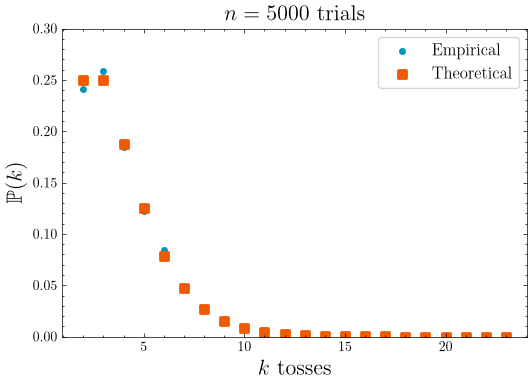

In [2]:
rng = np.random.default_rng(SEED)

def empirical(n): # empirically modeling the coin toss, n times
    # tosses up to and including a head are Geometric(1/2); exactly two heads = the sum of two
    numtosses = rng.geometric(0.5, size=(n, 2)).sum(axis=1)
    ks, counts = np.unique(numtosses, return_counts=True)  # count amount of each unique number of tosses
    return list(zip(ks, counts/n))

def theoretical(): # theoretical model of the coin toss
    k = np.arange(2, 24)
    return list(zip(k, (k-1)*(0.5)**k))

n = 5000

plt.figure(figsize=(6,4))
emp = plt.scatter(*zip(*empirical(n)), marker='.', color=C.cyan, linewidths=2) # use zip function since empirical(), theoretical() output list of tuples
theo = plt.scatter(*zip(*theoretical()), marker='s', color=C.orange, linewidths=2)
plt.title('$n={}$ trials'.format(n), fontsize=16)
plt.xlabel('$k$ tosses', fontsize=16)
plt.ylabel('$\mathbb{P}(k)$', fontsize=16)
plt.ylim(0, 0.3)
plt.legend((emp, theo), ('Empirical', 'Theoretical'), loc= 'upper right', frameon=True, fontsize=12)
savefig(plt.gcf(), 'chap1ex5.eps', bbox_inches=None)
plt.show()

# Interpretation: for n trials, the probability that we needed k tosses to get exactly two heads is P(k)..

10. You have probably heard it before. Now you can solve it rigorously. It is called the "Monty Hall Problem." A prize is placed at random behind one of three doors. You pick a door. To be concrete, let's suppose you always pick door 1. Now Monty Hall chooses one of the other two doors, opens it and shows you that it is empty. He then gives you the opportunity to keep your door or switch to the other unopened door. Should you stay or switch? Intuition suggests it doesn't matter. The correct answer is that you should switch. Prove it. It will help to specify the sample space and the relevant events carefully. Thus write $\Omega = \{ (\omega_1, \omega_2): \omega_i \in \{1,2,3\} \}$ where $\omega_1$ is where the prize is and $\omega_2$ is the door Monty opens.

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\1329149876.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.2, '$\mathbb{P}(n, \\text{hold}) \\rightarrow 1/3$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\1329149876.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.55, '$\mathbb{P}(n, \\text{switch}) \\rightarrow 2/3$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\1329149876.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
The PostScript backend does not support transparency; partially transparent artists will b

saved chap1ex10.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex10.eps


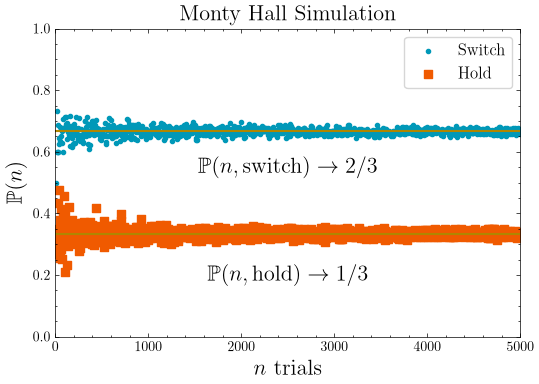

In [3]:
rng = np.random.default_rng(SEED)

def iterationswitch(n): # run the Monty Hall game n times, picking door 1 and switching
    prizedoor = rng.integers(1, 4, size=n)
    # if the prize is behind 2 or 3, Monty opens the other one; otherwise he picks 2 or 3 at random
    montypicks = np.where(prizedoor == 1, rng.integers(2, 4, size=n), 5 - prizedoor)
    yourswitch = 5 - montypicks  # the one of doors 2, 3 that Monty did not open
    return np.count_nonzero(yourswitch == prizedoor)/n

def iterationhold(n): # run the Monty Hall game n times, holding door 1
    prizedoor = rng.integers(1, 4, size=n)
    return np.count_nonzero(prizedoor == 1)/n

n = 5000
trials = list(range(10, n+1, 5)) # create list for numbers of trials
switchprob = [iterationswitch(i) for i in trials]
holdprob = [iterationhold(i) for i in trials]

plt.figure(figsize=(6,4))
switch = plt.scatter(trials, switchprob, marker='.', color=C.cyan, linewidths=1)
hold = plt.scatter(trials, holdprob, marker='s', color=C.orange, linewidths=1)
plt.hlines(1/3, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5, label='asfd')
plt.text(n/2, 0.2, '$\mathbb{P}(n, \\text{hold}) \\rightarrow 1/3$', ha='center', va='center', fontsize=16)
plt.text(n/2, 0.55, '$\mathbb{P}(n, \\text{switch}) \\rightarrow 2/3$', ha='center', va='center', fontsize=16)
plt.hlines(2/3, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.title('Monty Hall Simulation', fontsize=16)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,1)
plt.legend((switch, hold), ('Switch', 'Hold'), loc= 'upper right', frameon=True, fontsize=12)
savefig(plt.gcf(), 'chap1ex10.eps', bbox_inches=None)
plt.show()

12. There are three cards. The first is green on both sides, the second is red on both sides and the third is green on one side and red on the other. We choose a card at random and we see one side (also chosen at random). If the side we see if is green, what is the probability that the other side is also green? Many people intuitively answer $1/2$. Show that the correct answer is $2/3$.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\535940886.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.55, '$\mathbb{P}(n) \\rightarrow 2/3$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\535940886.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex12.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex12.eps


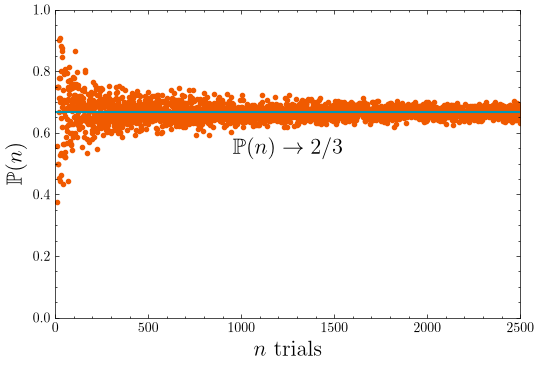

In [4]:
rng = np.random.default_rng(SEED)

def iteration(n): # run the card game n times
    card = rng.integers(0, 3, size=n)   # 0 = green/green, 1 = red/red, 2 = green/red
    side = rng.integers(0, 2, size=n)   # face showing; on the green/red card, side 0 is green
    green_GG = np.count_nonzero(card == 0)                   # draw green from GG
    green_GR = np.count_nonzero((card == 2) & (side == 0))   # draw green from GR
    return green_GG/(green_GG + green_GR)

n=2500
games = list(range(10, n+1))
cardprob = [iteration(i) for i in games]

plt.figure(figsize=(6,4))
trials = plt.scatter(range(10,n+1),cardprob, marker='.', color=C.orange, linewidths=1)
plt.text(n/2, 0.55, '$\mathbb{P}(n) \\rightarrow 2/3$', ha='center', va='center', fontsize=16)
plt.hlines(2/3, 0, n, colors=C.cyan, linestyles='solid', linewidths=1.5)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,1)
savefig(plt.gcf(), 'chap1ex12.eps', bbox_inches=None)
plt.show()

13. Suppose that a fair coin is tossed repeatedly until both a head and tail have appeared at least once.

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\1209805391.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.text(3.5, 0.25, '$\mathbb{P}(k=3) \\rightarrow 1/4$', ha='left', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\1209805391.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(k)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex13.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex13.eps


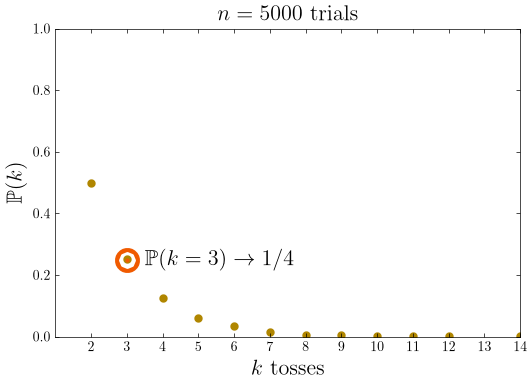

In [5]:
rng = np.random.default_rng(SEED)

def empirical(n): # empirically modeling the coin toss, n times
    # the first toss shows one face; then it takes Geometric(1/2) more tosses to see the other
    numtosses = 1 + rng.geometric(0.5, size=n)
    ks, counts = np.unique(numtosses, return_counts=True)  # count amount of each unique number of tosses
    return list(zip(ks, counts/n))

n = 5000

plt.figure(figsize=(6,4))
emp = plt.scatter(*zip(*empirical(n)), marker='.', color=C.yellow, linewidths=3) # use zip function since empirical(), theoretical() output list of tuples
plt.scatter(3, 0.25, marker='.', color=C.orange, linewidths=15)
plt.text(3.5, 0.25, '$\mathbb{P}(k=3) \\rightarrow 1/4$', ha='left', va='center', fontsize=16)
plt.title('$n={}$ trials'.format(n), fontsize=16)
plt.xlabel('$k$ tosses', fontsize=16)
plt.ylabel('$\mathbb{P}(k)$', fontsize=16)
plt.xlim(1,14)
plt.ylim(0, 1)
plt.xticks(np.arange(2,15,1))
plt.minorticks_off()
savefig(plt.gcf(), 'chap1ex13.eps', bbox_inches=None)
plt.show()

20. A box contains 5 coins and each has a different probability of showing heads. Let $p_1, ..., p_5$ denote the probability of heads on each coin. Suppose that

$$    p_1 = 0, \ p_2 = 1/4, \ p_3 = 1/2, \ p_4 = 3/4 \ \text{ and } \ p_5 = 1 $$

Let $H$ denote "heads is obtained" and let $C_i$ denote the event that coin $i$ is selected.

(a) Select a coin at random and toss it. Suppose a head is obainted. What is the posterior probability that coin $i$ was selected $(i = 1, ..., 5)$? In other words, find $\mathbb{P}(C_i | H)$ for $i = 1, ..., 5$.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\2401612407.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(C_i)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\2401612407.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.text(1, 0.1, '$\mathbb{P}(C_1 | H) \\rightarrow 0$', ha='right', va='center', fontsize=12, rotation=-20)
C:\Use

saved chap1ex20a.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex20a.eps


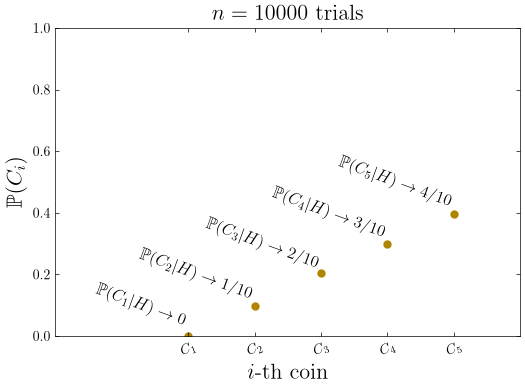

In [6]:
rng = np.random.default_rng(SEED)
headsprob = np.array([0, 0.25, 0.5, 0.75, 1])

def iteration(n):
  coin = rng.integers(1, 6, size=n)              # draw one of the five coins, n times
  heads = rng.random(n) < headsprob[coin-1]    # toss the drawn coin once
  return [np.count_nonzero(heads & (coin == i))/np.count_nonzero(heads) for i in range(1, 6)]

n = 10000

plt.figure(figsize=(6,4))
plt.scatter(list(range(1,6)), iteration(n), marker='.', color=C.yellow, linewidths=3) 
plt.title('$n={}$ trials'.format(n), fontsize=16)
plt.xlabel('$i$-th coin', fontsize=16)
plt.ylabel('$\mathbb{P}(C_i)$', fontsize=16)
plt.xlim(-1,6)
plt.xticks(np.arange(1,6,1), 
           ['$C_1$', '$C_2$', '$C_3$', '$C_4$', '$C_5$'],
            rotation=20)
plt.ylim(0, 1)
plt.text(1, 0.1, '$\mathbb{P}(C_1 | H) \\rightarrow 0$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(2, 0.2, '$\mathbb{P}(C_2 | H) \\rightarrow 1/10$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(3, 0.3, '$\mathbb{P}(C_3 | H) \\rightarrow 2/10$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(4, 0.4, '$\mathbb{P}(C_4 | H) \\rightarrow 3/10$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(5, 0.5, '$\mathbb{P}(C_5 | H) \\rightarrow 4/10$', ha='right', va='center', fontsize=12, rotation=-20)
plt.minorticks_off()
savefig(plt.gcf(), 'chap1ex20a.eps', bbox_inches=None)
plt.show()


(b) Toss the coin again. What is the probability of another head? In other words find $\mathbb{P}(H_2 | H_1)$ where $H_j = $ "heads on toss $j$."

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\3950703338.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.55, '$\mathbb{P}(n) \\rightarrow 3/4$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\3950703338.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex20b.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex20b.eps


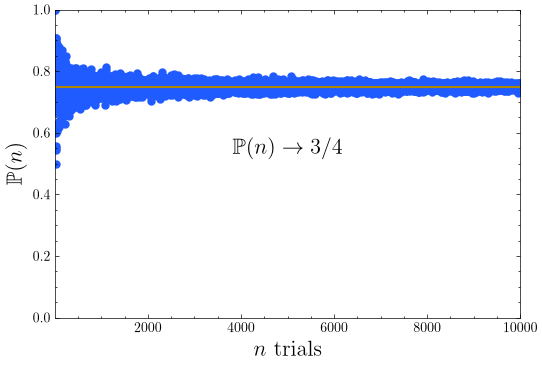

In [7]:
rng = np.random.default_rng(SEED)
headsprob = np.array([0, 0.25, 0.5, 0.75, 1])

def iteration(n):
  coin = rng.integers(1, 6, size=n)                       # draw one of the five coins
  tosses = rng.random((n, k)) < headsprob[coin-1, None]   # toss it k times (True = heads)
  firsttossheads = np.count_nonzero(tosses[:, 0])
  return np.count_nonzero(tosses[:, 0] & tosses[:, 1])/firsttossheads   # P(H_2 | H_1)

n, k, probs = 10000, 2, []

for i in range(10,n+1):
  probs.append(iteration(i))   # i trials for the i-th point

plt.figure(figsize=(6,4))
plt.scatter(list(range(10,n+1)), probs, marker='.', color=C.blue, linewidths=3) 
plt.text(n/2, 0.55, '$\mathbb{P}(n) \\rightarrow 3/4$', ha='center', va='center', fontsize=16)
plt.hlines(3/4, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
plt.xlim(10,n)
plt.ylim(0,1)
savefig(plt.gcf(), 'chap1ex20b.eps', bbox_inches=None)
plt.show()

(c) Find $\mathbb{P}(C_i | B_4)$ where $B_4 =$ "first head is obtained on toss 4."

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\653783592.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(C_i)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\653783592.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.text(1, 0.1, '$\mathbb{P}(C_1 | B_4) \\rightarrow 0$', ha='right', va='center', fontsize=12, rotation=-20)
C:\Use

saved chap1ex20c.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex20c.eps


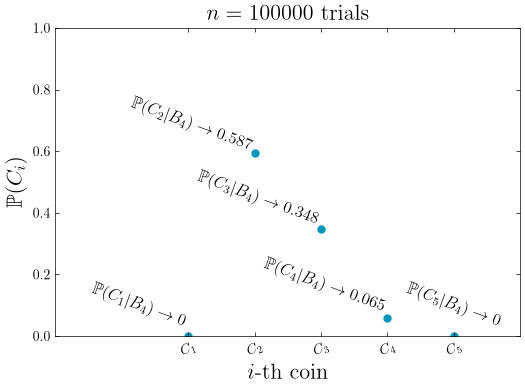

In [8]:
rng = np.random.default_rng(SEED)
headsprob = np.array([0, 0.25, 0.5, 0.75, 1])

def iteration(n):
  coin = rng.integers(1, 6, size=n)                       # draw one of the five coins
  tosses = rng.random((n, k)) < headsprob[coin-1, None]   # toss it k times (True = heads)
  B4 = ~tosses[:, 0] & ~tosses[:, 1] & ~tosses[:, 2] & tosses[:, 3]   # first head on toss 4
  return [(i, np.count_nonzero(B4 & (coin == i))/np.count_nonzero(B4)) for i in range(1, 6)]

n, k = 100000, 4

plt.figure(figsize=(6,4))
plt.scatter(*zip(*iteration(n)), marker='.', color=C.cyan, linewidths=3) 
plt.title('$n={}$ trials'.format(n), fontsize=16)
plt.xlabel('$i$-th coin', fontsize=16)
plt.ylabel('$\mathbb{P}(C_i)$', fontsize=16)
plt.xlim(-1,6)
plt.xticks(np.arange(1,6,1), 
           ['$C_1$', '$C_2$', '$C_3$', '$C_4$', '$C_5$'],
            rotation=20)
plt.ylim(0, 1)
plt.text(1, 0.1, '$\mathbb{P}(C_1 | B_4) \\rightarrow 0$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(2, 0.687, '$\mathbb{P}(C_2 | B_4) \\rightarrow 0.587$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(3, 0.448, '$\mathbb{P}(C_3 | B_4) \\rightarrow 0.348$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(4, 0.165, '$\mathbb{P}(C_4 | B_4) \\rightarrow 0.065$', ha='right', va='center', fontsize=12, rotation=-20)
plt.text(5, 0.1, '$\mathbb{P}(C_5 | B_4) \\rightarrow 0$', ha='center', va='center', fontsize=12, rotation=-20)
plt.minorticks_off()
savefig(plt.gcf(), 'chap1ex20c.eps', bbox_inches=None)
plt.show()

21. (Computer Experiment.) Suppose a coin has probability $p$ of falling heads up. If we flip the coin many times, we would expect the proportion of heads to be near $p$. We will make this formal later. Take $p = .3$ and $n = 1,000$ and simulate n coin flips. Plot the proportion of heads as a function of n. Repeat for $p = .03$.

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\3177388592.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.45, '$\mathbb{P}(n) \\rightarrow 0.3$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\3177388592.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex21i.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex21i.eps


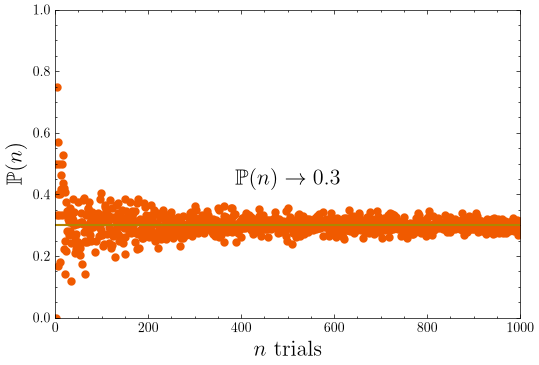

In [9]:
rng = np.random.default_rng(SEED)

def trials(n): # for each i = 1..n, flip i fresh coins and record the proportion of heads
    return [np.count_nonzero(rng.random(i) < 0.3)/i for i in range(1, n+1)]

n = 1000

plt.figure(figsize=(6,4))
plt.scatter(list(range(1,n+1)), trials(n), marker='.', color=C.orange, linewidths=3) 
plt.text(n/2, 0.45, '$\mathbb{P}(n) \\rightarrow 0.3$', ha='center', va='center', fontsize=16)
plt.hlines(0.3, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,1)
savefig(plt.gcf(), 'chap1ex21i.eps', bbox_inches=None)
plt.show()



<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_41964\727200316.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 0.15, '$\mathbb{P}(n) \\rightarrow 0.03$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_41964\727200316.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap1ex21ii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap1\chap1ex21ii.eps


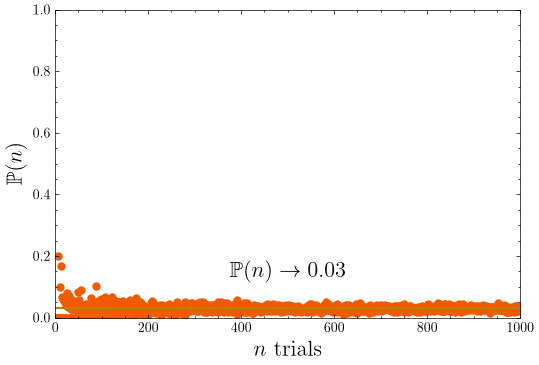

In [10]:
rng = np.random.default_rng(SEED)

def trials(n): # for each i = 1..n, flip i fresh coins and record the proportion of heads
    return [np.count_nonzero(rng.random(i) < 0.03)/i for i in range(1, n+1)]

n = 1000

plt.figure(figsize=(6,4))
plt.scatter(list(range(1,n+1)), trials(n), marker='.', color=C.orange, linewidths=3) 
plt.text(n/2, 0.15, '$\mathbb{P}(n) \\rightarrow 0.03$', ha='center', va='center', fontsize=16)
plt.hlines(0.03, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{P}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,1)
savefig(plt.gcf(), 'chap1ex21ii.eps', bbox_inches=None)
plt.show()

22. (Computer Experiment.) Suppose we flip a coin $n$ times and let $p$ denote the probability of heads. Let $X$ be the number of heads. We call $X$ a binomial random variable, which is discussed in the next chapter. Intuition suggests that $X$ will be close to $np$. To see if this is true, we can repeat this experiment many times and average the $X$ values. Carry out a simulation and compare the average of the $X$'s to $np$. Try this for $p = .3$ and $n=10, n = 100,$ and $n = 1,000$.

In [11]:
rng = np.random.default_rng(SEED)

def trials(n, k): # k experiments of n flips each; number of heads in each
    return np.count_nonzero(rng.random((k, n)) < 0.3, axis=1)

p, n1, n2, n3, k = 0.3, 10, 100, 1000, 1000 # n's are the numbers of times we flip coin, k is number of experiment trials
print("Running an experiment of", n1, "flips over", k, "trials, we average", np.mean(trials(n1,k)), "heads, compared to np =", n1*p)
print("Running an experiment of", n2, "flips over", k, "trials, we average", np.mean(trials(n2,k)), "heads, compared to np =", n2*p)
print("Running an experiment of", n3, "flips over", k, "trials, we average", np.mean(trials(n3,k)), "heads, compared to np =", n3*p)

Running an experiment of 10 flips over 1000 trials, we average 3.009 heads, compared to np = 3.0
Running an experiment of 100 flips over 1000 trials, we average 30.13 heads, compared to np = 30.0
Running an experiment of 1000 flips over 1000 trials, we average 299.746 heads, compared to np = 300.0


23. (Computer Experiment.) Here we will get some experience simulating conditional probabilities. Consider tossing a fair die. Let $A = \{2, 4, 6\}$ and $B = \{1,2,3,4\}$. Then, $\mathbb{P}(A) = 1/2, \mathbb{P}(B) = 2/3$, and $\mathbb{P}(AB) = 1/3$. Since $\mathbb{P}(AB) = \mathbb{P}(A)\mathbb{P}(B)$, the events $A$ and $B$ are independent. Simulate draws from the sample space and verify that $\widehat{\mathbb{P}}(AB) = \widehat{\mathbb{P}}(A)\widehat{\mathbb{P}}(B)$ where $\widehat{\mathbb{P}}(A)$ is the proportion of times $A$ occurred in the simulation and similarly for $\widehat{\mathbb{P}}(AB)$ and $\widehat{\mathbb{P}}(B)$. Now find two events $A$ and $B$ that are not independent. Compute $\widehat{\mathbb{P}}(A), \widehat{\mathbb{P}}(B)$ and $\widehat{\mathbb{P}}(AB)$. Compare the calculated values to their theoretical values. Report your results and interpret.

In [12]:
rng = np.random.default_rng(SEED)

def rolls(n): # n rolls of a fair die
    return list(rng.integers(1, 7, size=n))

n = 10000
sample = rolls(n)   # one sample; every probability below is estimated from it

# P(A)
prob_A = (sample.count(2) + sample.count(4) + sample.count(6))/n

# P(B)
prob_B = (sample.count(1) + sample.count(2) + sample.count(3) + sample.count(4))/n

# P(AB)
prob_AB = (sample.count(2) + sample.count(4))/n

print("P(A)P(B) =", prob_A*prob_B, "and P(AB) =", prob_AB, ". Thus A and B are independent.")



P(A)P(B) = 0.33568708999999997 and P(AB) = 0.3355 . Thus A and B are independent.


Now suppose we have $A = B = \{k\}$ where $k$ is any integer $1, ..., 6$. Then $\mathbb{P}(A) = \mathbb{P}(B) = \mathbb{P}(AB) = 1/6$, but $\mathbb{P}(A)\mathbb{P}(B) = 1/36$. Thus $A$ and $B$ are not independent. In general, we can conclude that any event cannot be independent of itself unless the probability of the event is either 0 or 1.

In [13]:
rng = np.random.default_rng(SEED)

def rolls(n): # n rolls of a fair die
    return list(rng.integers(1, 7, size=n))

n = 10000
sample = rolls(n)   # one sample; every probability below is estimated from it

# P(A)
prob_A = sample.count(1)/n

# P(B)
prob_B = sample.count(1)/n

# P(AB)
prob_AB = sample.count(1)/n

print("P(A)P(B) =", prob_A*prob_B, "and P(AB) =", prob_AB, ". Thus A and B are not independent.")

P(A)P(B) = 0.02742336 and P(AB) = 0.1656 . Thus A and B are not independent.
